# morris_lisp in Jupyter

Runs the Lisp interpreter with no PyQt6 GUI at all -- charts render inline, `display-columns` renders as a pandas table. See `lisp_jupyter.py` next to this notebook.

In [1]:
%load_ext lisp_jupyter

## Basics -- one shared environment across cells

In [2]:
%%lisp
(define (square n) (* n n))
(square 12)

144


144

In [3]:
%%lisp
; square is still bound here -- same environment as the cell above
(map square (list 1 2 3 4 5))

(1 4 9 16 25)


(1 4 9 16 25)

## Charts render inline

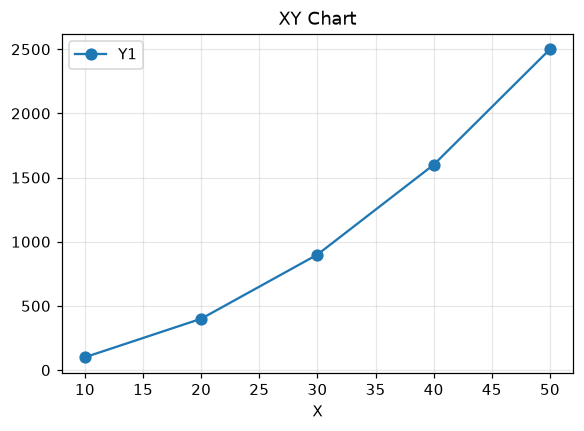

In [4]:
%%lisp
(define prices (vector 10 20 30 40 50))
(define squares (vector-map (lambda (x) (* x x)) prices))
(plot-xy prices (list squares))

## `display-columns` renders as a pandas table

`calculate-all` deliberately returns the topologically-sorted column list (handy for chaining straight into `write-csv`), not `'()` -- so it WOULD get echoed as a big `#S(column ...)` dump, same as any other non-`'()` value ending a cell. Ending the cell with a bare `'()` after it (as below) suppresses that; `display-columns` (which `calculate-all` already calls internally) is what actually shows the data.

In [5]:
%%lisp
(load "column_engine.lsp")
(load "prepayment_model.lsp")

(define mortgage_interest_rate 6.00)
(define periodic_mortgage_interest_rate (/ mortgage_interest_rate 1200.0))
(define mortgage_term 24)
(define mortgage_initial_balance 100000.0)
(define d_factor (pow (+ periodic_mortgage_interest_rate 1.0) mortgage_term))
(define mortgage_monthly_payment
  (* mortgage_initial_balance
     (/ (* periodic_mortgage_interest_rate d_factor) (- d_factor 1.0))))

(defcolumn balance_column
  :name "balance" :after ()
  :initial_value mortgage_initial_balance
  :value_calculation (- (* (lag balance 1) (+ 1 periodic_mortgage_interest_rate))
                        mortgage_monthly_payment)
  :decimals 2)

(calculate-all *columns* (+ mortgage_term 1))
'()

,balance
0,"100,000.00"
1,"96,067.94"
2,"92,116.22"
3,"88,144.74"
4,"84,153.40"
5,"80,142.11"
6,"76,110.76"
7,"72,059.25"
8,"67,987.48"
9,"63,895.36"


## `lisp(...)` also works as a plain function, no magic needed

In [6]:
from lisp_jupyter import lisp

lisp("(+ 1 2 3)")
total = lisp("(vector-sum squares)")
print("total from Python:", total)

6
5500
total from Python: 5500


## Errors are caught and printed cleanly, not a raw traceback

In [7]:
%%lisp
(+ 1 this-is-not-bound)

Error: unbound symbol: this-is-not-bound
